In [1]:
!pip install shap

In [ ]:
# !pip uninstall numpy
# !pip install numpy==1.26.4


^C
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    c:\users\dell\anaconda3\lib\site-packages\numpy-2.0.2-cp312-cp312-win_amd64.whl
    c:\users\dell\anaconda3\lib\site-packages\numpy-2.0.2.dist-info\*
    c:\users\dell\anaconda3\lib\site-packages\numpy.libs\libscipy_openblas64_-caad452230ae4ddb57899b8b3a33c55c.dll
    c:\users\dell\anaconda3\lib\site-packages\numpy.libs\msvcp140-23ebcc0b37c8e3d074511f362feac48b.dll
    c:\users\dell\anaconda3\lib\site-packages\numpy\*
    c:\users\dell\anaconda3\scripts\f2py.exe
    c:\users\dell\anaconda3\scripts\numpy-config.exe
Proceed (Y/n)? 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import shap

C:\Users\dell\anaconda3\envs\ecg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
df = pd.read_csv("../heart_hrv_cleaned.csv")

In [24]:
X = df.drop(columns=["label", "image"], errors='ignore')
y = df["label"]

In [25]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

In [27]:
#Feature preprocessing: handle missing/inf, scaling
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='passthrough'
)

# Fit transform the train and transform test
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp = preprocessor.transform(X_test)

Top features:
 HRV_MCVNN           0.033723
HRV_MedianNN        0.029990
HRV_Cd              0.028153
HRV_MeanNN          0.027806
HRV_Ca              0.026589
HRV_IQRNN           0.025832
HRV_MadNN           0.025816
HRV_SD2a            0.025527
HRV_Prc20NN         0.025503
HRV_AI              0.025361
HRV_FuzzyEn         0.025315
HRV_GI              0.024390
HRV_SI              0.023845
HRV_KFD             0.023151
HRV_MinNN           0.023074
HRV_CSI_Modified    0.023040
HRV_SDNNa           0.022737
HRV_C2d             0.022646
HRV_C1a             0.021562
HRV_C2a             0.021322
dtype: float64


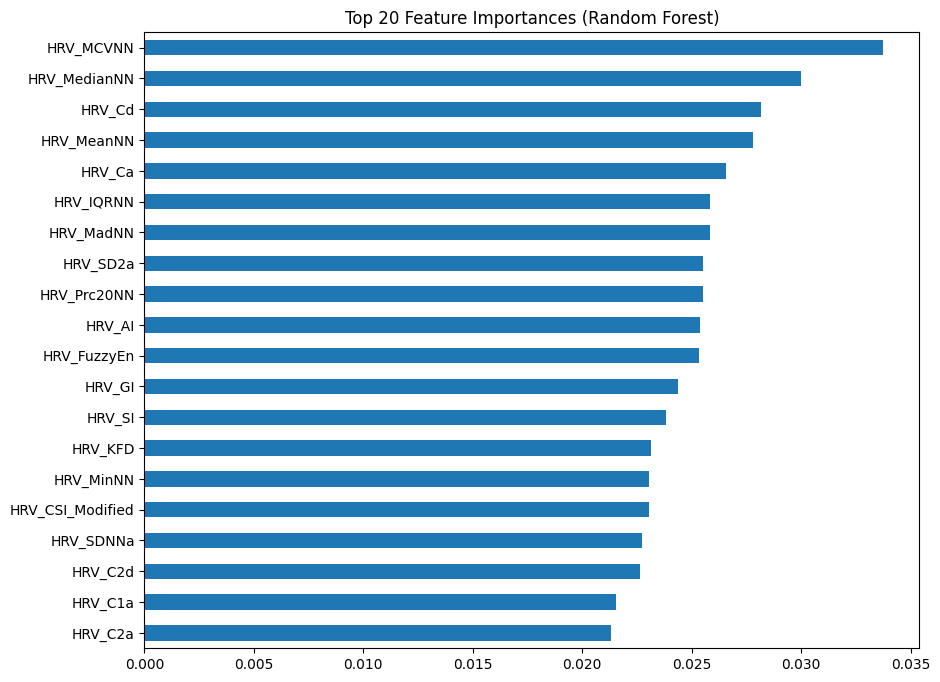

In [28]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_pp, y_train)

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=numeric_features).sort_values(ascending=False)
print("Top features:\n", feat_imp.head(20))

# Plot
plt.figure(figsize=(10,8))
feat_imp.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [29]:
topN = 30
top_features = feat_imp.head(topN).index.tolist()
print("Selected top features:", top_features)

# Reduce datasets
X_train_sel = pd.DataFrame(X_train_pp, columns=numeric_features)[top_features].values
X_test_sel = pd.DataFrame(X_test_pp, columns=numeric_features)[top_features].values

Selected top features: ['HRV_MCVNN', 'HRV_MedianNN', 'HRV_Cd', 'HRV_MeanNN', 'HRV_Ca', 'HRV_IQRNN', 'HRV_MadNN', 'HRV_SD2a', 'HRV_Prc20NN', 'HRV_AI', 'HRV_FuzzyEn', 'HRV_GI', 'HRV_SI', 'HRV_KFD', 'HRV_MinNN', 'HRV_CSI_Modified', 'HRV_SDNNa', 'HRV_C2d', 'HRV_C1a', 'HRV_C2a', 'HRV_C1d', 'HRV_Prc80NN', 'HRV_SD1SD2', 'HRV_SD2d', 'HRV_CVSD', 'HRV_SD1d', 'HRV_SD2', 'HRV_SD1a', 'HRV_SDNNd', 'HRV_SDRMSSD']


Accuracy: 0.8054054054054054
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.61      0.67        46
           1       0.88      0.65      0.75        34
           2       0.94      1.00      0.97        48
           3       0.72      0.89      0.80        57

    accuracy                           0.81       185
   macro avg       0.82      0.79      0.79       185
weighted avg       0.81      0.81      0.80       185



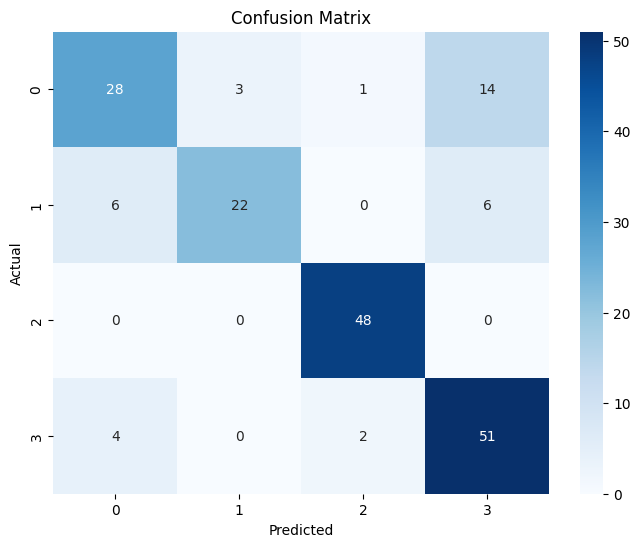

In [30]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
rf2 = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
lr = LogisticRegression(max_iter=500, random_state=42)

voting = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf2), ('lr', lr)],
    voting='soft',
    n_jobs=1
)
# Fit
voting.fit(X_train_sel, y_train)

# Predict & evaluate
y_pred = voting.predict(X_test_sel)
y_prob = voting.predict_proba(X_test_sel)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", 
      classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [31]:
# Prediction probabilities: show for a few samples
prob_df = pd.DataFrame(y_prob, columns=le.classes_)
print("\nSample probabilities:\n", prob_df.head())


Sample probabilities:
           0         1         2         3
0  0.167860  0.653833  0.084783  0.093525
1  0.148093  0.054877  0.109542  0.687488
2  0.208013  0.565954  0.067257  0.158776
3  0.141677  0.094726  0.187123  0.576474
4  0.078324  0.589075  0.146039  0.186562


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [03:50<00:00,  2.31s/it]


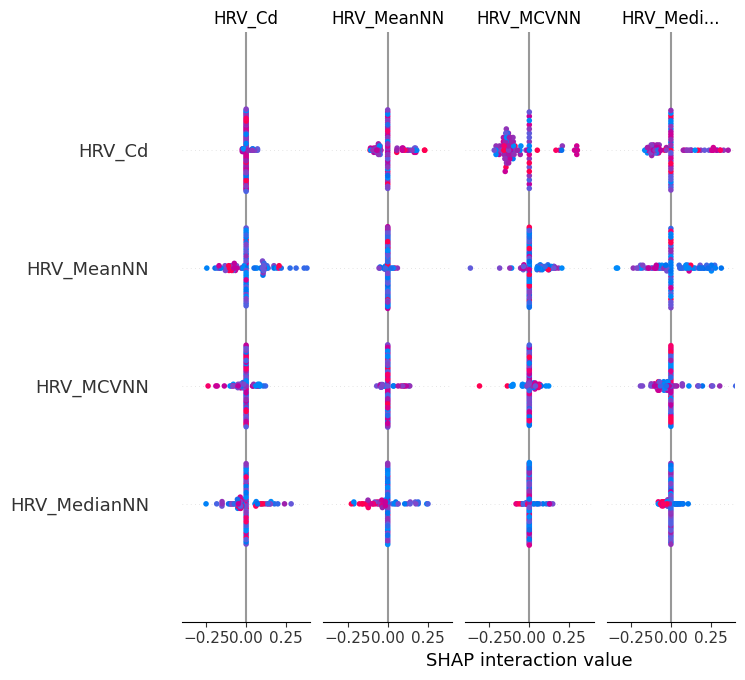

In [33]:
import shap

# 1. Fit the model
xgb.fit(X_train_sel, y_train)

# 2. Background data (smaller sample = faster)
background = shap.sample(X_train_sel, 100)

# 3. Create explainer
explainer = shap.KernelExplainer(
    lambda x: xgb.predict_proba(x),
    background
)

# 4. Compute SHAP values only for a subset (to avoid long runtime)
shap_values = explainer.shap_values(X_test_sel[:100])

# 5. Summary plot
shap.summary_plot(shap_values, 
                  X_test_sel[:100], 
                  feature_names=top_features)


In [34]:
import joblib
joblib.dump(voting, "heart_disease_ensemble_model.pkl")
joblib.dump(top_features, "top_features_list.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Models & feature list saved.")


Models & feature list saved.
